- Labels
- Each training and test example is assigned to one of the following labels:
- 
- 0 T-shirt/top
- 1 Trouser
- 2 Pullover
- 3 Dress
- 4 Coat
- 5 Sandal
- 6 Shirt
- 7 Sneaker
- 8 Bag
- 9 Ankle boot

[ fashoin 분류 ]
- 다중분류
- 지도학습 - 분류
- 이진분류

In [99]:
## 모듈로딩
import pandas as pd  # 데이터 모듈
import numpy as np

import torch         
# tensor 및 기본 함수 모듈   
import torch.nn as nn
# 인공신경망 관련 모듈
import torch.nn.functional as F
# 인공신경망 관련 함수
import torch.optim as optim
# 최적화 모듈

from sklearn.model_selection import train_test_split
# 학습용 데이터셋 관련 함수

In [100]:
fasDF = pd.DataFrame(pd.read_csv('../_data/fashion/fashion-mnist_train.csv', engine='python'))

[2] 데이터 로딩 및 확인 <hr> 

In [ ]:
fasDF.head()
fasDF.info()             

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 359.3 MB


In [103]:
featureTs = torch.LongTensor(fasDF.iloc[:,1:].values)
targetTs = torch.LongTensor(fasDF['label'].values)


In [81]:

X_train, X_test, y_train, y_test = train_test_split(
    featureTs, targetTs, train_size= 0.8, stratify=targetTs, random_state=42)

print(f"X_train => {X_train.ndim}D {X_train.shape} / X_test => {X_test.ndim}D, {X_test.shape}")
print(f"y_train => {y_train.ndim}D {y_train.shape}, / y_test => {y_test.ndim}D, {y_test.shape}")

X_train => 2D torch.Size([48000, 784]) / X_test => 2D, torch.Size([12000, 784])
y_train => 1D torch.Size([48000]), / y_test => 1D, torch.Size([12000])


[4] 모델 클래스 설계 및 구현 <hr>

In [82]:
""" 
데이터셋 iris: 피쳐 4, 타겟 1. 타겟은 범주형 3가지
학습 방법은 : 범주형이므로 분류 - 
구현알고리즘: 인공신경망 DNN
	  입력        퍼셉트론    활성화함수
입력층 784          400       RELU
은닉충  400         200 	      RELU
은닉충  200         100 	      RELU
은닉충  100         50 	      RELU
출력층  50	    	10		  SoftMax => 손실함수내에 포함

"""

class fas_Model(nn.Module):
    # 인스턴스 초기화 및 생성 메서드
    def __init__(self):
        super().__init__() #부모(nn.Module)의 init 생성
        print('__init__()')
        self.layers = nn.Sequential(
                        nn.Linear(784, 400),
                        nn.ReLU(),
                        nn.Linear(400, 200),
                        nn.ReLU(),
                        nn.Linear(200, 100),
                        nn.ReLU(),
                        nn.Linear(100, 50),
                        nn.ReLU(),
                        nn.Linear(50, 10),
                        
        )

    # 순전파 학습 메서드 
    def forward(self, data):
        return self.layers(data)
               

[5] 학습 준비<hr>

In [83]:
## [5-1] 학습 관련 설정들
EPOCH = 1000                                         # 학습용 DS를 처음부터 끝까지 1번 학습하는 것을 에포크
BATCH_SIZE = 1200                                      # DS를 학습량 만큼 나눈 사이즈
ITERATION = int(X_train.shape[0]/BATCH_SIZE)         # 학습용 DS이 분리된 수 => 1에포크에 W, b 업데이트 횟수
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"DEVICE : {DEVICE}, EPOCHS : {EPOCH}, BATCH_SIZE : {BATCH_SIZE} ITERATION: {ITERATION}")
      

DEVICE : cpu, EPOCHS : 1000, BATCH_SIZE : 1200 ITERATION: 40


In [84]:
# [5-2] 학습 관련 인스턴스들
LR      = 0.0001                                # Learning Rate
MODEL  = fas_Model()                           #학습 모델
OPTIMIZER = optim.Adam(MODEL.parameters(), lr=LR)      #최적화 즉, 경사하강법 알고리즘으로 W, b의 값 개신
LOSS_FN = nn.CrossEntropyLoss()


__init__()


In [85]:
# 학습함수
def training():
    #학습 모드 설정
    MODEL.train()

    E_LOSS = 0
    for i in range(ITERATION):
        start = i*BATCH_SIZE
        end = start + BATCH_SIZE
        
        #nadrray ==> tensor 변환
        # 처음부터 텐서로 데이터 가르기를 하면 추가 변환이 필요없다.
        # x = torch.FloatTensor(X_train.values[start:end])
        # y = torch.FloatTensor(y_train.values[start:end])
        
        #가중치 기울기 0 초기화
        OPTIMIZER.zero_grad()
        
        #학습 진행
        # pre_y = MODEL(x)
        pre_y = MODEL(X_train[start:end])
        
        # 손실 계산
        # loss = LOSS_FN(pre_y, y.reshape(-1,1))
        loss = LOSS_FN(pre_y, y_train[start:end].reshape(-1).long())
        
        #역전파 진행
        loss.backward()
        
        #가중치/절편 업데이트
        OPTIMIZER.step()
        
        E_LOSS += loss.item()
        
    # print(f"[EPOCH = {epoch}], LOSS {E_LOSS/ITERATION}")
    return loss.item()

In [86]:
training()

0.6241569519042969

In [87]:
## 검증함수
## 검증용 데이터셋으로 모델 검증
## 학습 지속여부 결정 기준이 됨
## -----
def evaluate():
    # 에포크 단위로 검증 => 검증 모드
    MODEL.eval()
    
    # W, b가 업데이트 해제
    with torch.no_grad():
        # 검증용 데이터셋 => 텐서화
        # ndarray  ==> tensor 변환
        # x = torch.FloatTensor(X_test.values)
        # y = torch.FloatTensor(y_test.values)
        
        #검증진행
        # pre_y = MODEL(x)
        pre_y = MODEL(X_test)
        
        # 손실 계산
        # loss = LOSS_FN(pre_y, y.reshape(-1,1))
        loss = LOSS_FN(pre_y, y_test.reshape(-1).long())
        # 1차원 long 타입 요구.
        
        
    return loss.item()
        
        
        

In [88]:
evaluate()

0.6052100658416748

In [89]:
# 방법 2: time 모듈 사용
import time

# 현재 시간을 초 단위로 출력
print(time.time())

# 포맷팅된 시간 출력
print(time.strftime("%H:%M:%S"))

1743155842.6621556
18:57:22


In [93]:
# 에포크 : DS 처음부터 ~ 끝까지 학습
LOSS_HIST = {'Train':[], 'Valid':[]}

#에포크 단위 학습/검증 진행
print(time.strftime("%H:%M:%S"))
for epoch in range(EPOCH):
    a = time.time()
    trainLoss = training()
    validLoss = evaluate()
    
    LOSS_HIST['Train'].append(trainLoss)
    LOSS_HIST['Valid'].append(validLoss)
    
    print(f"\nEPOCH[{epoch}/{EPOCH}]-------------")
    print(f" - TRAIN_LOSS {trainLoss:.5f}")
    print(f" - VALID_LOSS {validLoss:.5f}")
    
    print(time.time()-a)
print(time.strftime("%H:%M:%S"))

18:59:51

EPOCH[0/1000]-------------
 - TRAIN_LOSS 0.04237
 - VALID_LOSS 0.65907
0.8118185997009277

EPOCH[1/1000]-------------
 - TRAIN_LOSS 0.02324
 - VALID_LOSS 0.62026
0.7650816440582275

EPOCH[2/1000]-------------
 - TRAIN_LOSS 0.03388
 - VALID_LOSS 0.60698
0.7605409622192383

EPOCH[3/1000]-------------
 - TRAIN_LOSS 0.05349
 - VALID_LOSS 0.60597
0.7699391841888428

EPOCH[4/1000]-------------
 - TRAIN_LOSS 0.02326
 - VALID_LOSS 0.63587
0.7423841953277588

EPOCH[5/1000]-------------
 - TRAIN_LOSS 0.02470
 - VALID_LOSS 0.64615
0.7525818347930908

EPOCH[6/1000]-------------
 - TRAIN_LOSS 0.03344
 - VALID_LOSS 0.68943
0.7559628486633301

EPOCH[7/1000]-------------
 - TRAIN_LOSS 0.02846
 - VALID_LOSS 0.69187
0.7403678894042969

EPOCH[8/1000]-------------
 - TRAIN_LOSS 0.01658
 - VALID_LOSS 0.65571
0.7430984973907471

EPOCH[9/1000]-------------
 - TRAIN_LOSS 0.01915
 - VALID_LOSS 0.61822
0.7851946353912354

EPOCH[10/1000]-------------
 - TRAIN_LOSS 0.01640
 - VALID_LOSS 0.63045
0.803446

In [94]:
evaluate()

1.3073350191116333

In [95]:
# MODEL.eval()
xdata = range(1000)
ydata1 = LOSS_HIST['Train']
ydata2 = LOSS_HIST['Valid']
ydata = np.linspace(0,1,1000)

In [96]:
type(xdata), type(ydata1), type(ydata2)

(range, list, list)

In [97]:
import matplotlib.pyplot as plt

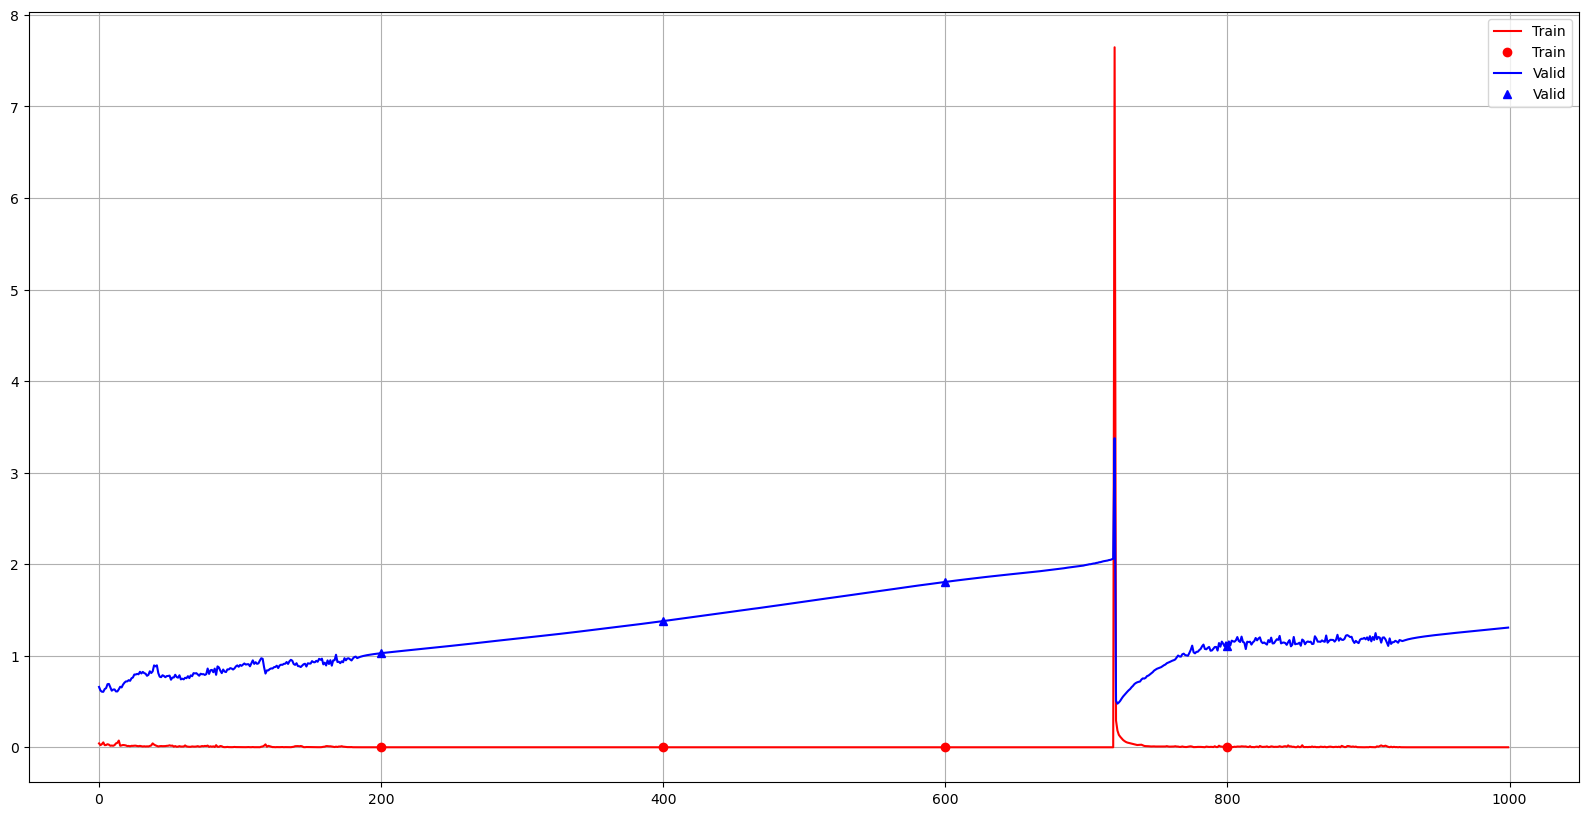

In [98]:
plt.figure(figsize=(20,10))
plt.plot(xdata, ydata1, 'r-', label ='Train')
plt.plot(xdata[200::200], ydata1[200::200], 'ro', label ='Train')
plt.plot(xdata, ydata2, 'b-', label ='Valid')
plt.plot(xdata[200::200], ydata2[200::200], 'b^', label ='Valid')

plt.legend()
plt.grid()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

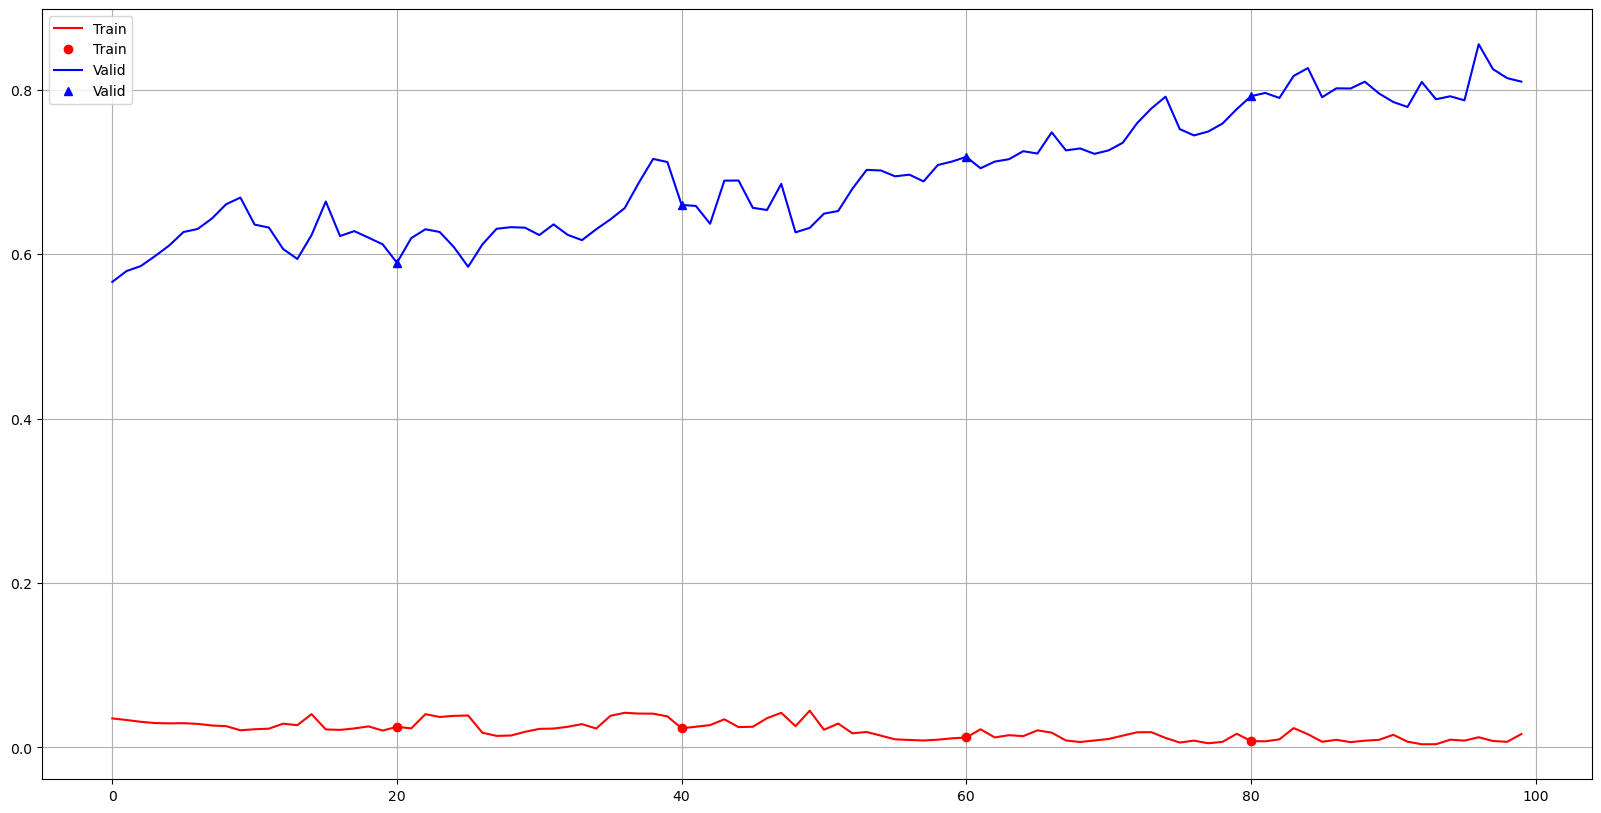

In [ ]:
plt.figure(figsize=(20,10))
plt.plot(xdata, ydata1, 'r-', label ='Train')
plt.plot(xdata[20::20], ydata1[20::20], 'ro', label ='Train')
plt.plot(xdata, ydata2, 'b-', label ='Valid')
plt.plot(xdata[20::20], ydata2[20::20], 'b^', label ='Valid')

plt.legend()
plt.grid()
plt.show()